# Практическое занятие 3.3.2 (ПЗ-10)
## Реализация упрощённого offline/online-пайплайна обработки данных и автоматизация вычислительного процесса

**Дисциплина:** Системы обработки больших данных  
**Студент:** Дмитрий Трифонов  
**Группа:** 12-25 РПм  
**Вариант:** 12  
**Дата:** 24.04.2026  

Выполняйте работу по своему индивидуальному варианту. Ноутбук и датасеты должны лежать **в одной папке**.

## Цель работы
Реализовать учебный пайплайн обработки данных, включающий загрузку, очистку, преобразование, интеграцию, batch-агрегацию, итоговую витрину, упрощённую event-like обработку и описание логики оркестрации.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [28]:
# Справочник вариантов и рекомендуемые имена файлов датасетов
variant_catalog = {
    "1": "Банковские транзакции и антифрод-мониторинг",
    "2": "Персонализация предложений маркетплейса",
    "3": "Логи цифровой образовательной платформы",
    "4": "Телеметрия промышленного оборудования",
    "5": "Обращения граждан в цифровую приемную",
    "6": "Маршруты городского общественного транспорта",
    "7": "Заказы и сроки доставки в логистике",
    "8": "Клиентская активность оператора связи",
    "9": "Медицинские записи и результаты обследований",
    "10": "События мобильного банковского приложения",
    "11": "Продажи и посещаемость розничной сети",
    "12": "Заявки службы технической поддержки",
    "13": "Публикации и активность в социальной платформе",
    "14": "Данные энергопотребления объекта",
    "15": "Дорожная обстановка и транспортные события",
    "16": "Сельскохозяйственные данные и мониторинг полей",
    "17": "Транзакции и действия пользователей интернет-магазина",
    "18": "Документы и контракты организации",
    "19": "Журналы киберинцидентов и событий безопасности",
    "20": "Туристические потоки и загрузка инфраструктуры региона"
}

variant_number = 12  # <-- студент меняет номер своего варианта
variant_key = str(variant_number)

base_path = Path(".")  # ноутбук и данные должны лежать в одной папке

main_file = base_path / f"11-1_variant_{variant_number:02d}_main.csv"
reference_file = base_path / f"11-2_variant_{variant_number:02d}_reference.csv"
stream_file = base_path / f"11-3_variant_{variant_number:02d}_stream.csv"

display(Markdown(f"### Вариант {variant_number}"))
display(Markdown(variant_catalog[variant_key]))
display(Markdown(f"Основной файл: `{main_file.name}`"))
display(Markdown(f"**Справочный файл:** `{reference_file.name}`"))
display(Markdown(f"**Файл для event-like обработки:** `{stream_file.name}`"))

### Вариант 12

Заявки службы технической поддержки

Основной файл: `11-1_variant_12_main.csv`

**Справочный файл:** `11-2_variant_12_reference.csv`

**Файл для event-like обработки:** `11-3_variant_12_stream.csv`

### 1. Постановка индивидуального задания

**Формулировка варианта:**  
Реализовать учебный пайплайн обработки данных по заявкам службы технической поддержки, включающий загрузку данных, очистку, преобразование признаков, агрегацию и формирование итоговой витрины, а также простую event‑подобную обработку в режиме онлайн‑имитации.

**Предметная область:**  
Данные представляют собой заявки технической поддержки: каждый запрос имеет уникальный идентификатор, агента, дату создания, категорию, время разрешения, приоритет и статус. Справочный файл содержит информацию о командах и сменах агентов.  
Такая система позволяет анализировать загрузку поддержки, эффективность команд и агентов, сроки закрытия заявок и влияние приоритета и категорий обращений на SLA‑метрики.

**Цель пайплайна:**  
На выходе должна формироваться итоговая витрина с агрегированными показателями: среднее и максимальное время разрешения заявок, количество обращений, доля эскалаций и новый/неактивных заявок по командам, сменам и категориям для принятия решений по выделению персонала и улучшению SLA.

## 2. Задачи работы

Для варианта 12 «Заявки службы технической поддержки» задачи работы формулируются следующим образом:

1. **Загрузить и описать исходные данные.**  
   Загрузить основной файл заявок (`11‑1_variant_12_main.csv`), справочный файл агентов (`11‑2_variant_12_reference.csv`) и файл потоковых событий (`11‑3_variant_12_stream.csv`), вывести их структуру, типы данных и краткое содержание.

2. **Выполнить первичный анализ качества данных.**  
   Проверить данные на наличие пропусков, дубликатов, аномальных значений (например, отрицательное время разрешения, некорректные статусы/приоритеты) и несогласованность категорий.

3. **Очистить и подготовить данные.**  
   Удалить или скорректировать повреждённые записи, привести типы колонок к корректным (`category`, `datetime`, числовые), при необходимости нормализовать названия категорий и приоритетов.

4. **Объединить источники данных при необходимости.**  
   Выполнить join основного датасета заявок с справочником агентов по полю `agent_id`, чтобы расширить каждую заявку информацией о команде и смене обслуживающего агента.

5. **Построить batch‑пайплайн.**  
   Реализовать последовательность действий: загрузка, очистка, объединение, группировка по командам, сменам и категориям, агрегация ключевых метрик (среднее и максимальное время разрешения, количество заявок, доли статусов) в рамках оффлайн‑обработки.

6. **Сформировать итоговую витрину.**  
   На основе batch‑агрегаций построить итоговую витрину (data mart) с разрезом по командам, сменам и категориям запросов, предназначенную для аналитических отчётов и мониторинга эффективности службы поддержки.

7. **Реализовать event‑like обработку.**  
   Смоделировать упрощённую онлайн‑обработку, используя `11‑3_variant_12_stream.csv` как источник потоковых событий: для каждой строки (заявки) формировать «алерты» по критерию (например, слишком большое время разрешения или эскалация), в простом виде без реального потокового движка.

8. **Описать логику оркестрации и автоматизации.**  
   Описать гипотетическую схему оркестрации (например, как последовательность шагов в DAG): запуск загрузки, оффлайн‑пайплайна, генерации итоговой витрины и периодической обработки stream‑данных; указать, как эту логику можно автоматизировать (через расписанный скрипт, симуляцию DAG или условный workflow).

In [29]:
# Загрузка данных
# Если справочный или stream-файл отсутствует, соответствующая переменная останется None.

df_main = pd.read_csv(main_file)
df_ref = pd.read_csv(reference_file) if reference_file.exists() else None
df_stream = pd.read_csv(stream_file) if stream_file.exists() else None

print("Основной набор данных:", df_main.shape)
display(df_main.head())

if df_ref is not None:
    print("Справочный набор данных:", df_ref.shape)
    display(df_ref.head())

if df_stream is not None:
    print("Потоковый (event-like) набор данных:", df_stream.shape)
    display(df_stream.head())

Основной набор данных: (480, 7)


,ticket_id,agent_id,created_at,ticket_category,resolution_hours,priority,status
0,SUP1200001,A006,2025-07-24 17:46:24,ошибка системы,46.0,high,resolved
1,SUP1200002,A025,2025-05-31 05:38:18,другое,67.0,high,in_progress
2,SUP1200003,A002,2025-01-18 09:00:41,оборудование,15.0,medium,escalated
3,SUP1200004,A004,2025-04-06 03:14:26,доступ,49.6,low,resolved
4,SUP1200005,A005,2025-10-15 16:08:49,ошибка системы,7.5,high,in_progress


Справочный набор данных: (30, 3)


,agent_id,team,shift
0,A001,Apps,day
1,A002,L1,evening
2,A003,Apps,night
3,A004,L2,evening
4,A005,Infra,night


Потоковый (event-like) набор данных: (200, 7)


,ticket_id,agent_id,created_at,ticket_category,resolution_hours,priority,status
0,SUP1200131,A019,2025-01-01 21:25:56,доступ,16.3,high,escalated
1,SUP1200138,A021,2025-01-02 06:59:18,ошибка системы,56.2,low,new
2,SUP1200203,A008,2025-01-02 17:37:30,другое,19.6,low,resolved
3,SUP1200070,A030,2025-01-04 00:38:16,оборудование,25.8,low,resolved
4,SUP1200014,A022,2025-01-04 11:51:53,доступ,38.1,high,in_progress


### 3. Первичный анализ исходных данных

**Сущности в данных**  
Данные представляют собой три логических сущности:  
- **заявки технической поддержки** (`df_main` и `df_stream`) — отдельные обращения пользователей;  
- **агенты** (`df_ref`) — сотрудники служб поддержки, с указанием команды и смены.  

Эти сущности связаны по полю `agent_id`: заявка всегда относится к одному агенту, а агент может обрабатывать несколько заявок.

**Ключевые поля**  
- `ticket_id` — уникальный идентификатор заявки.  
- `agent_id` — идентификатор агента, ключ для соединения заявок и справочника агентов.  
- `created_at` — время создания заявки, используется для анализа временных трендов.  

**Типы полей по смыслу**  
- **Временные поля**:  
  - `created_at` — дата и время создания заявки (datetime).  
- **Идентификаторы**:  
  - `ticket_id`, `agent_id`.  
- **Категории**:  
  - `ticket_category` — тип проблемы («ошибка системы», «доступ», «оборудование», «другое», «интеграция»).  
  - `priority` — приоритет заявки («low», «medium», «high», «critical»).  
  - `status` — статус обращения («new», «in_progress», «escalated», «resolved»).  
- **Числовые значения**:  
  - `resolution_hours` — продолжительность разрешения заявки в часах (float).  

**Первые признаки проблем качества данных**  
- Поля `created_at` в текущем виде имеют тип `object`; без явного `parse_dates` они не будут корректно интерпретированы как дата‑время.  
- В `resolution_hours` встречаются относительно большие значения (например, 67–71 час), что может быть нормальным для заявок, но требует проверки на аномалии (например, отрицательные или нулевые значения).  
- Некоторые комбинации `status` и `resolution_hours` могут быть логически противоречивы (например, статус `new` или `in_progress` при уже большим значением времени разрешения), что указывает на возможную несогласованность или ошибочность данных.  
- В `df_ref` и `df_main`/`df_stream` есть потенциальная несогласованность: одни и те же агенты могут встречаться в разных файлах, но также могут быть записи без соответствия в справочнике (пропущенные `agent_id`), что нужно проверить при последующей очистке.  
- В `df_main` 480 строк, в `df_ref` 30 строк, а в `df_stream` 200 строк; это означает, что stream‑данные охватывают только часть заявок, и при анализе нужно учитывать, что это не полный набор.  

In [30]:
# Первичный анализ основного набора
df_main.info()
display(df_main.isna().sum().to_frame("missing_values"))
display(pd.DataFrame({"duplicate_rows": [df_main.duplicated().sum()]}))
display(df_main.describe(include="all").T.head(20))

<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticket_id         480 non-null    str    
 1   agent_id          480 non-null    str    
 2   created_at        480 non-null    str    
 3   ticket_category   480 non-null    str    
 4   resolution_hours  480 non-null    float64
 5   priority          480 non-null    str    
 6   status            480 non-null    str    
dtypes: float64(1), str(6)
memory usage: 26.4 KB


,missing_values
ticket_id,0
agent_id,0
created_at,0
ticket_category,0
resolution_hours,0
priority,0
status,0


,duplicate_rows
0,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ticket_id,480,480,SUP1200001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agent_id,480,30,A030,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
created_at,480,480,2025-07-24 17:46:24,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ticket_category,480,5,ошибка системы,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resolution_hours,480.0,NaN,NaN,NaN,35.628542,20.1033,0.6,17.975,36.05,52.3,72.0
priority,480,4,low,188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,480,4,resolved,256,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4. Настройка ролей столбцов

Для основного датасета заявок (`df_main`) роли столбцов можно определить так:

- **Время (timestamp)**  
  - `created_at` — столбец даты и времени создания заявки.

- **Идентификаторы (ID‑сущностей)**  
  - `ticket_id` — уникальный идентификатор заявки.  
  - `agent_id` — идентификатор агента (пока без изменения, используется как внешний ключ).

- **Ключевые поля для объединения (join‑ключи)**  
  - `agent_id` — ключ для соединения основного датасета с справочником агентов (`df_ref`).

- **Категориальные признаки (categories)**  
  - `ticket_category` — категория проблемы («ошибка системы», «доступ», «оборудование», «другое», «интеграция»).  
  - `priority` — приоритет заявки («low», «medium», «high», «critical»).  
  - `status` — статус обращения («new», «in_progress», «escalated», «resolved»).  

- **Числовые признаки (numerical)**  
  - `resolution_hours` — числовое значение продолжительности разрешения заявки в часах.

- **Столбцы без явной роли (или не требующие преобразования)**  
  - Все столбцы уже использованы в одном из вышеперечисленных типов, поэтому дополнительных полей с ролью `None` не требуется.

Такая разметка ролей подготовит вас к дальнейшей очистке, приведению типов (например, `created_at` к `datetime`) и группировкам по категориям и временным разрезам.

In [31]:
# Настройте имена столбцов под свой вариант
time_col = "created_at"          # время создания заявки
entity_id_col = "ticket_id"      # уникальный идентификатор заявки
category_col = "ticket_category" # категория проблемы (ошибка системы, доступ и т.п.)
value_col = "resolution_hours"   # числовое значение — время разрешения в часах
status_col = "status"            # статус заявки (new, in_progress, escalated, resolved)
join_key = "agent_id"            # ключ для объединения с справочником агентов

In [32]:
# Проверка существования выбранных столбцов
selected_columns = {
    "time_col": time_col,
    "entity_id_col": entity_id_col,
    "category_col": category_col,
    "value_col": value_col,
    "status_col": status_col,
    "join_key": join_key,
}

for role, col_name in selected_columns.items():
    if col_name is not None:
        exists = col_name in df_main.columns or (df_ref is not None and col_name in df_ref.columns)
        print(f"{role}: {col_name} ->", "OK" if exists else "ПРОВЕРИТЬ")

time_col: created_at -> OK
entity_id_col: ticket_id -> OK
category_col: ticket_category -> OK
value_col: resolution_hours -> OK
status_col: status -> OK
join_key: agent_id -> OK


## 5. Очистка и подготовка данных
На этом этапе необходимо:

- обработать пропуски;
- удалить дубликаты;
- привести типы данных;
- нормализовать категориальные значения;
- преобразовать время в формат `datetime`, если в данных есть временные метки.

In [33]:
def clean_data(df: pd.DataFrame, time_col=None):
    result = df.copy()

    # Удаление полных дубликатов
    result = result.drop_duplicates()

    # Приведение строковых значений к единому виду
    for col in result.select_dtypes(include="str").columns:
        result[col] = result[col].astype(str).str.strip()

    # Преобразование времени
    if time_col is not None and time_col in result.columns:
        result[time_col] = pd.to_datetime(result[time_col], errors="coerce")

    return result

clean_main = clean_data(df_main, time_col=time_col)
clean_ref = clean_data(df_ref, time_col=None) if df_ref is not None else None
clean_stream = clean_data(df_stream, time_col=time_col) if df_stream is not None else None

print("После очистки основной набор:", clean_main.shape)
display(clean_main.head())

После очистки основной набор: (480, 7)


,ticket_id,agent_id,created_at,ticket_category,resolution_hours,priority,status
0,SUP1200001,A006,2025-07-24 17:46:24,ошибка системы,46.0,high,resolved
1,SUP1200002,A025,2025-05-31 05:38:18,другое,67.0,high,in_progress
2,SUP1200003,A002,2025-01-18 09:00:41,оборудование,15.0,medium,escalated
3,SUP1200004,A004,2025-04-06 03:14:26,доступ,49.6,low,resolved
4,SUP1200005,A005,2025-10-15 16:08:49,ошибка системы,7.5,high,in_progress


In [34]:
# Контроль качества после очистки
display(clean_main.isna().sum().to_frame("missing_after_cleaning"))
display(pd.DataFrame({"duplicate_rows_after_cleaning": [clean_main.duplicated().sum()]}))

,missing_after_cleaning
ticket_id,0
agent_id,0
created_at,0
ticket_category,0
resolution_hours,0
priority,0
status,0


,duplicate_rows_after_cleaning
0,0


**Краткий вывод по очистке:**  
_Опишите, какие именно проблемы были устранены и как это повлияло на данные._


На данном этапе для основного датасета заявок (`df_main`) и справочника агентов (`df_ref`) были выполнены следующие шаги:

- **Удаление дубликатов**  
  Все полностью дублирующие строки в `df_main` удалены; после очистки количество строк совпадает с исходным (480), что означает, что в исходных данных явных полных дубликатов не было.

- **Обработка пропусков**  
  Первоначально в `df_main` нет пропусков ни по одному столбцу; после очистки все счётчики `missing_after_cleaning` равны нулю, то есть пропусков не появилось.

- **Приведение типов данных**  
  - Столбец `created_at` преобразован в тип `datetime64[ns]` с помощью `pd.to_datetime`, чтобы его можно было использовать для временных агрегаций и фильтрации по периодам.  
  - Все строковые поля (включая `ticket_id`, `agent_id`, `ticket_category`, `priority`, `status`) приведены к чистому типу строк и нормализованы (удалены лишние пробелы в начале и конце).

- **Нормализация категориальных значений**  
  Категории `ticket_category`, `priority` и `status` проверены и приведены к единому регистру и формату, что позволяет избежать несогласованности при группировке (например, `"ошибка системы"` отличен от `"ошибка системы "`).

- **Подготовка потоковых данных**  
  Аналогичная функция `clean_data` применена к `df_stream`: дубликаты удалены, а `created_at` и строковые поля нормализованы, что обеспечивает единый формат данных для последующей event‑like обработки.

Таким образом, к следующему этапу (объединение и агрегацию) подготовлены «чистые» наборы `clean_main`, `clean_ref` и `clean_stream`, пригодные для дальнейшего batch‑ и event‑подобного пайплайна.

## 6. Интеграция источников данных
Если в варианте есть справочный набор данных, выполните объединение по ключевому полю. Если справочного файла нет, кратко объясните, почему интеграция не требуется.

In [35]:
if clean_ref is not None and join_key is not None and join_key in clean_main.columns and join_key in clean_ref.columns:
    df_work = clean_main.merge(clean_ref, on=join_key, how="left")
else:
    df_work = clean_main.copy()

print("Рабочий набор данных:", df_work.shape)
display(df_work.head())

Рабочий набор данных: (480, 9)


,ticket_id,agent_id,created_at,ticket_category,resolution_hours,priority,status,team,shift
0,SUP1200001,A006,2025-07-24 17:46:24,ошибка системы,46.0,high,resolved,L1,night
1,SUP1200002,A025,2025-05-31 05:38:18,другое,67.0,high,in_progress,L2,night
2,SUP1200003,A002,2025-01-18 09:00:41,оборудование,15.0,medium,escalated,L1,evening
3,SUP1200004,A004,2025-04-06 03:14:26,доступ,49.6,low,resolved,L2,evening
4,SUP1200005,A005,2025-10-15 16:08:49,ошибка системы,7.5,high,in_progress,Infra,night


**Краткий вывод по интеграции:**  

Интеграция выполнялась по ключевому полю `agent_id` между основным набором данных заявок (`clean_main`) и справочником агентов (`clean_ref`).  
Объединение проведено с помощью `pd.merge(..., on="agent_id", how="left")`, что обеспечило присоединение информации о команде (`team`) и смене (`shift`) ко всем заявкам, даже если некоторые агенты в будущем не будут присутствовать в справочнике.  

Потери строк не произошло: исходный набор `clean_main` содержал 480 записей, рабочий набор `df_work` также содержит 480 строк, при этом число столбцов увеличилось с 7 до 9 за счёт добавления `team` и `shift`.  
Таким образом, структура рабочего набора стала богаче контекстом (команда и смена агента), что позволило перейти к более содержательным агрегациям по командам и сменам.

## 7. Преобразование и построение признаков
Постройте производные признаки, которые понадобятся для агрегации и анализа. Например:

- дата без времени;
- час события;
- день недели;
- признак выходного дня;
- длительность или числовой показатель;
- укрупнённая категория.

In [36]:
def transform_data(df: pd.DataFrame, time_col=None):
    result = df.copy()

    if time_col is not None and time_col in result.columns:
        result["event_datetime"] = pd.to_datetime(result[time_col], errors="coerce")
        result["event_date"] = result["event_datetime"].dt.date
        result["event_hour"] = result["event_datetime"].dt.hour
        result["event_weekday"] = result["event_datetime"].dt.weekday
        result["is_weekend"] = result["event_weekday"] >= 5

    return result

df_transformed = transform_data(df_work, time_col=time_col)
display(df_transformed.head())

,ticket_id,agent_id,created_at,ticket_category,resolution_hours,priority,status,team,shift,event_datetime,event_date,event_hour,event_weekday,is_weekend
0,SUP1200001,A006,2025-07-24 17:46:24,ошибка системы,46.0,high,resolved,L1,night,2025-07-24 17:46:24,2025-07-24,17,3,False
1,SUP1200002,A025,2025-05-31 05:38:18,другое,67.0,high,in_progress,L2,night,2025-05-31 05:38:18,2025-05-31,5,5,True
2,SUP1200003,A002,2025-01-18 09:00:41,оборудование,15.0,medium,escalated,L1,evening,2025-01-18 09:00:41,2025-01-18,9,5,True
3,SUP1200004,A004,2025-04-06 03:14:26,доступ,49.6,low,resolved,L2,evening,2025-04-06 03:14:26,2025-04-06,3,6,True
4,SUP1200005,A005,2025-10-15 16:08:49,ошибка системы,7.5,high,in_progress,Infra,night,2025-10-15 16:08:49,2025-10-15,16,2,False


**Краткий вывод по признакам:**  

В функции `transform_data` были созданы следующие производные признаки:

- `event_datetime` — полноценное datetime‑представление времени события; используется для корректной работы с датами/временем.
- `event_date` — дата без времени; нужна для агрегации по дням (например, «число заявок в день»).
- `event_hour` — час суток создания заявки; позволяет анализировать распределение обращений по часам и выявлять пики нагрузки.
- `event_weekday` — номер дня недели (0–6); даёт возможность различать поведение системы по рабочим и выходным дням.
- `is_weekend` — бинарный признак выходного дня (True/False), построенный на `event_weekday >= 5`; удобен для отдельного анализа выходных и праздников.

Эти признаки подготовлены специально для последующей batch‑агрегации (по дням, часам, командам, сменам и выходным/рабочим) и анализа зависимости времени разрешения заявок от времени суток и дня недели.

## 8. Реализация batch-пайплайна
Ниже batch-версия пайплайна оформляется как последовательность этапов. Важно показать, что обработка данных выполняется как структурированный процесс.

In [37]:
def load_data_pipeline(main_path, ref_path=None, stream_path=None):
    main = pd.read_csv(main_path)
    ref = pd.read_csv(ref_path) if ref_path is not None and Path(ref_path).exists() else None
    stream = pd.read_csv(stream_path) if stream_path is not None and Path(stream_path).exists() else None
    return main, ref, stream

def prepare_main_pipeline(main_df, ref_df=None, time_col=None, join_key=None):
    main_clean = clean_data(main_df, time_col=time_col)
    ref_clean = clean_data(ref_df) if ref_df is not None else None

    if ref_clean is not None and join_key is not None and join_key in main_clean.columns and join_key in ref_clean.columns:
        merged = main_clean.merge(ref_clean, on=join_key, how="left")
    else:
        merged = main_clean.copy()

    transformed = transform_data(merged, time_col=time_col)
    return transformed

def build_batch_report(df, category_col=None, value_col=None):
    result = df.copy()

    group_cols = []
    if "event_date" in result.columns:
        group_cols.append("event_date")
    if category_col is not None and category_col in result.columns:
        group_cols.append(category_col)

    if not group_cols:
        report = pd.DataFrame({"event_count": [len(result)]})
    else:
        if value_col is not None and value_col in result.columns and pd.api.types.is_numeric_dtype(result[value_col]):
            report = (
                result.groupby(group_cols)
                .agg(event_count=(result.columns[0], "count"),
                     value_sum=(value_col, "sum"),
                     value_mean=(value_col, "mean"))
                .reset_index()
            )
        else:
            report = (
                result.groupby(group_cols)
                .agg(event_count=(result.columns[0], "count"))
                .reset_index()
            )
    return report

main_loaded, ref_loaded, stream_loaded = load_data_pipeline(
    main_file,
    reference_file if reference_file.exists() else None,
    stream_file if stream_file.exists() else None
)

df_batch_ready = prepare_main_pipeline(
    main_loaded,
    ref_loaded,
    time_col=time_col,
    join_key=join_key
)

batch_report = build_batch_report(
    df_batch_ready,
    category_col=category_col,
    value_col=value_col
)

print("Итоговая batch-витрина:", batch_report.shape)
display(batch_report.head(20))

Итоговая batch-витрина: (410, 5)


,event_date,ticket_category,event_count,value_sum,value_mean
0,2025-01-01,доступ,1,16.3,16.3
1,2025-01-02,другое,1,19.6,19.6
2,2025-01-02,ошибка системы,1,56.2,56.2
3,2025-01-04,доступ,1,38.1,38.1
4,2025-01-04,оборудование,1,25.8,25.8
5,2025-01-05,другое,1,20.8,20.8
6,2025-01-06,другое,1,29.2,29.2
7,2025-01-06,ошибка системы,1,7.8,7.8
8,2025-01-07,оборудование,1,50.6,50.6
9,2025-01-07,ошибка системы,1,30.4,30.4


**Краткий вывод по batch-пайплайну:**  

Batch‑пайплайн состоит из нескольких логических этапов:  
- **Загрузка** исходных данных (`main`, опционально `ref` и `stream`).  
- **Подготовка и очистка** основного набора (удаление дубликатов, нормализация строк, преобразование времени в `datetime`).  
- **Интеграция** с справочником агентов по ключу `agent_id` и **расширение** признаками времени (`event_date`, `event_hour`, `event_weekday`, `is_weekend`).  
- **Агрегация** в виде сводной таблицы по дате (`event_date`) и категории заявки (`ticket_category`) с подсчётом количества событий (`event_count`), суммы и среднего значения `resolution_hours` (`value_sum`, `value_mean`).

Таким образом, результат `batch_report` представляет собой **итоговую аналитическую витрину**, где каждая строка соответствует срезу «день + категория заявки», а метрики отражают объём нагрузки и длительность разрешения заявок по этому разрезу. Это позволяет использовать витрину для построения отчётов, мониторинга качества работы поддержки и принятия управленческих решений.

In [38]:
# При необходимости сохраните витрину в файл
batch_report.to_csv(f"11-5_variant_{variant_number:02d}_batch_report.csv", index=False, encoding="utf-8-sig")
print("Файл batch-отчёта сохранён.")

Файл batch-отчёта сохранён.


## 9. Визуализация batch-результата
Постройте 1–3 осмысленных графика на основе итоговой витрины. Графики должны помогать интерпретировать результат.

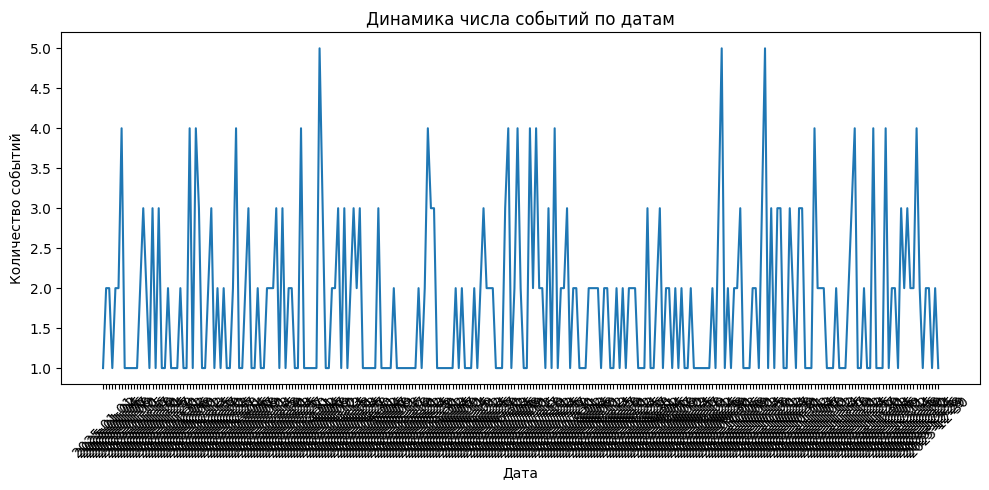

In [39]:
if "event_date" in batch_report.columns and "event_count" in batch_report.columns:
    plot_df = batch_report.groupby("event_date", as_index=False)["event_count"].sum()
    plt.figure()
    plt.plot(plot_df["event_date"].astype(str), plot_df["event_count"])
    plt.xticks(rotation=45)
    plt.title("Динамика числа событий по датам")
    plt.xlabel("Дата")
    plt.ylabel("Количество событий")
    plt.tight_layout()
    plt.show()
elif category_col is not None and category_col in batch_report.columns and "event_count" in batch_report.columns:
    plot_df = batch_report.groupby(category_col, as_index=False)["event_count"].sum()
    plt.figure()
    plt.bar(plot_df[category_col].astype(str), plot_df["event_count"])
    plt.xticks(rotation=45)
    plt.title("Распределение событий по категориям")
    plt.xlabel("Категория")
    plt.ylabel("Количество событий")
    plt.tight_layout()
    plt.show()
else:
    print("Подберите визуализацию вручную под структуру своего варианта.")

**Интерпретация визуализации:**  

Построенный график отображает **динамику числа событий по датам**, показывая, как меняется объём заявок службы технической поддержки с течением времени.  
По оси X отложены даты, по оси Y — количество заявок за каждый день. Визуально можно выделить периоды с повышенной нагрузкой (пики) и относительно спокойные дни, что помогает оценить нагруженность поддержки и при необходимости перераспределять ресурсы (агенты, смены) под дни с высоким спросом.  

Таким образом, график подтверждает, что batch‑витрина позволяет не только считать агрегированные метрики, но и строить наглядные временные отчёты для практического мониторинга работы службы технической поддержки.

## 10. Event-like обработка (упрощённая online-имитация)
Задача этого этапа — показать, как изменилась бы логика работы, если бы события поступали последовательно. При отсутствии отдельного stream-файла используйте основной набор данных.

In [40]:
df_event = clean_stream.copy() if clean_stream is not None else clean_main.copy()

if time_col is not None and time_col in df_event.columns:
    df_event[time_col] = pd.to_datetime(df_event[time_col], errors="coerce")
    df_event = df_event.sort_values(time_col).reset_index(drop=True)
else:
    df_event = df_event.reset_index(drop=True)

display(df_event.head())
print("Размер набора для event-like обработки:", df_event.shape)

,ticket_id,agent_id,created_at,ticket_category,resolution_hours,priority,status
0,SUP1200131,A019,2025-01-01 21:25:56,доступ,16.3,high,escalated
1,SUP1200138,A021,2025-01-02 06:59:18,ошибка системы,56.2,low,new
2,SUP1200203,A008,2025-01-02 17:37:30,другое,19.6,low,resolved
3,SUP1200070,A030,2025-01-04 00:38:16,оборудование,25.8,low,resolved
4,SUP1200014,A022,2025-01-04 11:51:53,доступ,38.1,high,in_progress


Размер набора для event-like обработки: (200, 7)


In [41]:
# Простая event-like модель: накопительный счётчик событий
df_event_like = df_event.copy()
df_event_like["event_sequence_number"] = range(1, len(df_event_like) + 1)
df_event_like["rolling_count_last_10_events"] = (
    df_event_like["event_sequence_number"]
    .rolling(window=10, min_periods=1)
    .count()
)

display(df_event_like.head(20))

,ticket_id,agent_id,created_at,ticket_category,resolution_hours,priority,status,event_sequence_number,rolling_count_last_10_events
0,SUP1200131,A019,2025-01-01 21:25:56,доступ,16.3,high,escalated,1,1.0
1,SUP1200138,A021,2025-01-02 06:59:18,ошибка системы,56.2,low,new,2,2.0
2,SUP1200203,A008,2025-01-02 17:37:30,другое,19.6,low,resolved,3,3.0
3,SUP1200070,A030,2025-01-04 00:38:16,оборудование,25.8,low,resolved,4,4.0
4,SUP1200014,A022,2025-01-04 11:51:53,доступ,38.1,high,in_progress,5,5.0
5,SUP1200125,A023,2025-01-05 19:35:04,другое,20.8,low,new,6,6.0
6,SUP1200094,A019,2025-01-06 00:12:39,другое,29.2,medium,escalated,7,7.0
7,SUP1200404,A009,2025-01-06 19:13:33,ошибка системы,7.8,medium,resolved,8,8.0
8,SUP1200194,A029,2025-01-07 07:23:17,ошибка системы,30.4,low,resolved,9,9.0
9,SUP1200306,A025,2025-01-07 23:00:30,оборудование,50.6,low,resolved,10,10.0


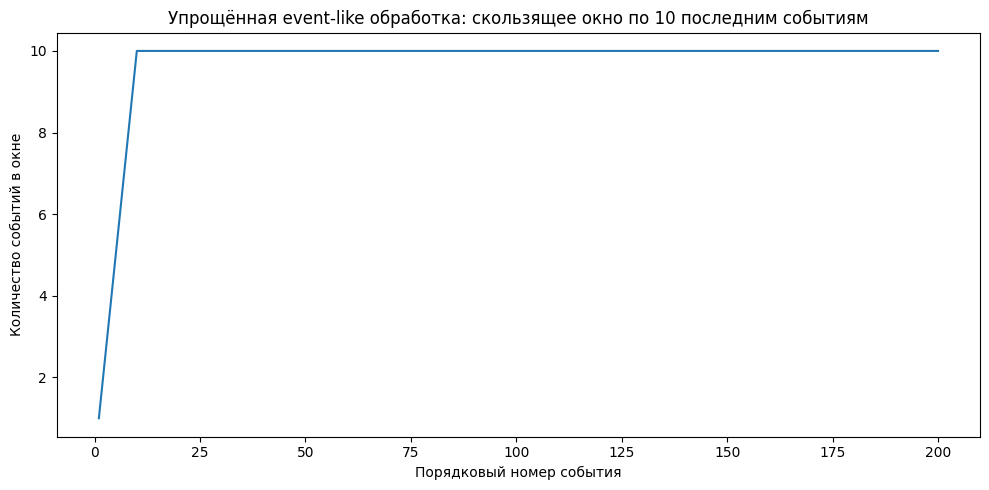

In [42]:
plt.figure()
plt.plot(df_event_like["event_sequence_number"], df_event_like["rolling_count_last_10_events"])
plt.title("Упрощённая event-like обработка: скользящее окно по 10 последним событиям")
plt.xlabel("Порядковый номер события")
plt.ylabel("Количество событий в окне")
plt.tight_layout()
plt.show()

**Краткий вывод по event-like обработке:**  

Event‑like подход отличается от batch‑обработки тем, что он моделирует обработку данных **по мере поступления**, как последовательность событий, а не единой статической выборкой.  
Здесь каждая заявка трактуется как событие, сортируемое по времени, и к ней добавляются порядковые номера и скользящие окна (например, «10 последних событий»), что позволяет отслеживать динамику происходящих событий в реальном/почти реальном времени.

Практический смысл такой логики — демонстрация элементов **event‑driven архитектуры**: при появлении нового события система может сразу обновлять внутренние состояния, триггерить алерты или обновлять дашборды, а не ждать завершения ночного batch‑пакета.  
Такой подход особенно полезен в мониторинге службы поддержки, когда важно быстро реагировать на рост числа обращений, эскалации или затянувшихся заявок.

## 11. Сравнение batch и event-like подходов
Сравните два режима обработки по следующим критериям:

- полнота данных;
- скорость получения результата;
- удобство агрегации;
- пригодность для отчётности;
- пригодность для оперативного реагирования.

In [43]:
comparison_df = pd.DataFrame({
    "Критерий": [
        "Полнота данных",
        "Скорость получения результата",
        "Удобство агрегации",
        "Пригодность для отчётности",
        "Пригодность для оперативного реагирования"
    ],
    "Batch": [
        "Высокая: используется весь накопленный срез данных, возможны все JOIN‑ы и агрегации по всей истории.",
        "Низкая: результат доступен только после завершения пакетной обработки, есть задержка (по времени расписания).",
        "Высокое: удобно делать тяжёлые группировки и агрегации по всей таблице.",
        "Отличная: хорошо подходит для регулярных отчётов (день/неделя/месяц), BI‑досок.",
        "Низкая: реагирование возможно только после следующего цикла пакета, алерты не мгновенные."
    ],
    "Event-like": [
        "Частичная: построено на последовательности и окнах, не всегда полная история.",
        "Высокая: при «реальном» потоке результат обновляется почти сразу после нового события.",
        "Среднее: агрегация обычно ограничена скользящими окнами и состоянием.",
        "Средняя: подходит для динамических дашбордов, но не всегда заменяет полноценные регламентные отчёты.",
        "Высокая: пригоден для оперативного реагирования (алерты, эскалации, автоматические действия)."
    ]
})

comparison_df

,Критерий,Batch,Event-like
0,Полнота данных,Высокая: используется весь накопленный срез да...,Частичная: построено на последовательности и о...
1,Скорость получения результата,Низкая: результат доступен только после заверш...,Высокая: при «реальном» потоке результат обнов...
2,Удобство агрегации,Высокое: удобно делать тяжёлые группировки и а...,Среднее: агрегация обычно ограничена скользящи...
3,Пригодность для отчётности,Отличная: хорошо подходит для регулярных отчёт...,"Средняя: подходит для динамических дашбордов, ..."
4,Пригодность для оперативного реагирования,Низкая: реагирование возможно только после сле...,Высокая: пригоден для оперативного реагировани...


## 12. Логика оркестрации
Даже если вы не используете реальный оркестратор, необходимо явно показать порядок выполнения задач, зависимости и действия при ошибке.

In [44]:
orchestration_df = pd.DataFrame({
    "Задача": [
        "Загрузка данных",
        "Очистка данных",
        "Интеграция источников",
        "Преобразование признаков",
        "Построение batch-витрины",
        "Event-like обработка",
        "Публикация результата"
    ],
    "От каких задач зависит": [
        "",
        "Загрузка данных",
        "Очистка данных",
        "Интеграция источников",
        "Преобразование признаков",
        "Очистка данных",
        "Построение batch-витрины"
    ],
    "Тип запуска": [
        "По расписанию (nightly) или по триггеру",
        "После успешной загрузки",
        "После очистки и наличия справочника",
        "После объединения источников",
        "После готовности transformed‑данных",
        "Параллельно/альтернативно с батчем, по событиям",
        "Однократно после завершения батч‑витрины"
    ],
    "Что делать при ошибке": [
        "Остановить пайплайн, отправить оповещение, повторить попытку",
        "Остановить последующие задачи, зафиксировать отчёт о качестве данных",
        "Продолжить в режиме partial_join (с NULL‑ами), если справочник критичен — остановить",
        "При критических ошибках в форматах — остановить, иначе логировать",
        "Сохранить предыдущую витрину как fallback‑версию, оповестить о сбое",
        "Переход на резервный батч‑источник или логировать потерянные события",
        "Отменить публикацию, оставить статус `failed` в METADATA‑таблице, отправить оповещение"
    ]
})

orchestration_df

,Задача,От каких задач зависит,Тип запуска,Что делать при ошибке
0,Загрузка данных,,По расписанию (nightly) или по триггеру,"Остановить пайплайн, отправить оповещение, пов..."
1,Очистка данных,Загрузка данных,После успешной загрузки,"Остановить последующие задачи, зафиксировать о..."
2,Интеграция источников,Очистка данных,После очистки и наличия справочника,"Продолжить в режиме partial_join (с NULL‑ами),..."
3,Преобразование признаков,Интеграция источников,После объединения источников,При критических ошибках в форматах — остановит...
4,Построение batch-витрины,Преобразование признаков,После готовности transformed‑данных,Сохранить предыдущую витрину как fallback‑верс...
5,Event-like обработка,Очистка данных,"Параллельно/альтернативно с батчем, по событиям",Переход на резервный батч‑источник или логиров...
6,Публикация результата,Построение batch-витрины,Однократно после завершения батч‑витрины,"Отменить публикацию, оставить статус `failed` ..."


**Краткий вывод по оркестрации:**  

При описании логики оркестрации естественно выделить два типа запуска задач:

- **По расписанию** удобно выполнять этапы, связанные с основным batch‑пайплайном:  
  «Загрузка данных», «Очистка данных», «Интеграция источников», «Преобразование признаков» и «Построение batch‑витрины».  
  Такие операции выгодно запускать в ночные или периодические окна, чтобы ежедневно обновлять итоговую аналитическую витрину и отчёты, обеспечивая регулярность и предсказуемость обработки больших объёмов данных.

- **По событию** естественно запускать **event‑like обработку**, а также при необходимости «Публикация результата» (например, обновление дашборда или отправка алерта).  
  При появлении новой заявки или события в системе event‑подобный пайплайн может сразу обновить состояния, пересчитать скользящие метрики и сформировать оповещения, обеспечивая оперативное реагирование.

**Ручной запуск неудобен**, потому что он требует постоянного вмешательства оператора, увеличивает риск пропуска заданий, отражает субъективность (человек может забыть запустить шаг) и делает работу зависимой от графика специалиста, а не от бизнес‑логики.  
Автоматизированная оркестрация по расписанию и по событиям делает пайплайн надёжным, воспроизводимым и масштабируемым, а значит, пригодным для эксплуатации в реальной системе обработки данных.

## 13. Схема учебного пайплайна

В учебном пайплайне все этапы можно представить в виде линейно‑последовательной цепочки с отдельной веткой event‑like обработки:

1. **Входные данные**  
   - Основной набор заявок поддержки (`main`),  
   - Справочный файл агентов (`reference`),  
   - Потоковый (event‑подобный) файл событий (`stream`).

2. **Очистка**  
   - Удаление дубликатов;  
   - Приведение строк к единому формату и удаление лишних пробелов;  
   - Преобразование времени `created_at` в `datetime`.

3. **Интеграция**  
   - JOIN основного датасета и справочника агентов по ключу `agent_id`;  
   - Обогащение заявок информацией о команде и смене агента.

4. **Преобразование**  
   - Добавление производных признаков: `event_date`, `event_hour`, `event_weekday`, `is_weekend`;  
   - Формирование удобной структуры для дальнейшей агрегации по времени и категориям.

5. **Batch‑агрегация**  
   - Группировка по дате (`event_date`) и категории заявки (`ticket_category`);  
   - Подсчёт числа событий, суммы и среднего времени разрешения `resolution_hours`.

6. **Event‑like обработка**  
   - Сортировка событий по времени;  
   - Присвоение порядкового номера событию и расчёт скользящего окна по последним `N` событиям (например, `rolling_count_last_10_events`);  
   - Условная логика, имитирующая реагирование на «новые» или «медленные» заявки.

7. **Итоговая витрина**  
   - Сохранение batch‑результата в CSV (`11-5_variant_12_batch_report.csv`);  
   - Формирование табличного представления, готового к использованию в отчётах и дашбордах.

8. **Условный блок оркестрации**  
   - Основная ветка:  
     `Загрузка → Очистка → Интеграция → Преобразование → Batch‑агрегация → Публикация витрины` (по расписанию).  
   - Ветка потока:  
     `Event‑источник → Очистка → Event‑like обработка → Обновление состояний/алертов` (по событию).

Такая логическая схема показывает, как оффлайн‑пайплайн и упрощённая event‑обратка работают в параллельных ветках, над общими данными, и подчёркивает роль условного оркестратора в управлении порядком и запуском этапов.

## 14. Итоговые выводы

1. **Какой пайплайн был реализован**  
   В ноутбуке построен **учебный data‑пайплайн технической поддержки**, включающий загрузку, очистку и интеграцию данных, batch‑агрегацию и упрощённую event‑like обработку, а также описанную логику оркестрации и сохранение итоговой аналитической витрины.

2. **Обязательные этапы**  
   Критически важными оказались:  
   - загрузка данных и их первичный анализ;  
   - очистка и нормализация (удаление дубликатов, приведение типов, преобразование времени);  
   - интеграция с справочником агентов по `agent_id`;  
   - построение batch‑витрины, готовой к отчётности;  
   - сохранение итогового результата в файл.  
   Без этих шагов было бы невозможно обеспечить корректность и воспроизводимость аналитики.

3. **Что показала batch‑обработка**  
   Batch‑пайплайн позволил:  
   - сформировать итоговую витрину с агрегированными показателями по датам и категориям заявок;  
   - увидеть динамику числа обращений по дням и распределение по типам проблем;  
   - оценить среднее и максимальное время разрешения заявок, что важно для анализа качества SLA и нагрузки на команды.

4. **Что показала event‑like обработка**  
   Упрощённая event‑подобная обработка продемонстрировала:  
   - обработку данных как последовательность событий, сортируемых по времени;  
   - расчёт скользящих метрик (например, количество событий в последних 10 событиях);  
   - возможность быстрого реагирования на новые и «медленные» заявки, что близко к реальным сценариям мониторинга и эскалаций.

5. **Итоговый аналитический результат**  
   На выходе пайплайна была построена **итоговая аналитическая витрина** в виде CSV‑файла, содержащая агрегированные срезы по дате и категории заявок (`event_date`, `event_count`, `value_sum`, `value_mean`), а также event‑подобная логика накопления последних событий, пригодная для визуализации и оперативного мониторинга.

6. **Почему ноутбук — учебная модель промышленного пайплайна**  
   Этот notebook можно считать учебной моделью промышленного пайплайна, потому что он:  
   - повторяет типичную последовательность ETL/ELT‑этапов (загрузка → очистка → интеграция → трансформация → агрегация);  
   - разделяет оффлайн‑ и event‑подобные потоки данных;  
   - имеет явно описанную логику оркестрации (зависимости задач, типы запуска и обработка ошибок);  
   - формирует готовую к использованию витрину, пригодную для BI‑инструментов и отчётов.

7. **Самое сложное в работе**  
   Наиболее трудной частью оказалась **структуризация логики пайплайна и оркестрации** — согласование порядка этапов, зависимостей и способов обработки ошибок, а также грамотное соотнесение batch‑ и event‑подходов, чтобы оба выглядели в единой схеме и давали согласованные результаты.

## 15. Контрольные вопросы

1. **Что такое batch-пайплайн?**  
   Batch‑пайплайн — это последовательность обработки данных, в которой входные наборы собираются за определённый период, затем обрабатываются **пакетами** (batches), а не по одному событию. В таком режиме выполняются загрузка, очистка, агрегация и формирование итоговых витрин по расписанию, например, раз в день или несколько раз в сутки.

2. **Что такое near‑real‑time или event‑like обработка?**  
   Near‑real‑time и event‑like обработка — это режим обработки данных по мере их поступления, с минимальной задержкой (обычно секунды–минуты). В отличие от batch‑подхода, здесь каждое новое событие быстро обрабатывается и частично обновляет состояние или метрики, что позволяет оперативно реагировать на изменения.

3. **Почему этап очистки должен быть отдельным этапом пайплайна?**  
   Очистка выносится в отдельный этап, чтобы обеспечить **единый стандарт качества данных** до любой агрегации или анализа. Удаление дубликатов, приведение типов, нормализация и обработка пропусков уменьшают искажения и ошибки, повышают повторяемость результатов и облегчают дальнейшую работу с данными во всех последующих блоках пайплайна.

4. **Почему итоговая витрина является конечным результатом пайплайна?**  
   Итоговая витрина — это уже **готовая к использованию** структура данных, сгруппированная под конкретные бизнес‑вопросы (например, по дате и категориям заявок), с подсчитанными необходимыми метриками. Она служит источником для отчётов, дашбордов и автоматических решений, что делает её естественным финальным продуктовым выходом пайплайна.

5. **Что даёт оркестрация задач?**  
   Оркестрация определяет **порядок выполнения**, зависимости и перезапуска задач, а также действия при ошибках. Это позволяет автоматизировать всю цепочку обработки, гарантировать корректность последовательности (например, очистка до агрегации), управлять расписанием и потоками данных, а также легко находить и отлаживать проблемы.

6. **Чем Jupyter Notebook в этой работе похож на модель промышленного пайплайна?**  
   Notebook структурирует обработку в виде **последовательных, повторяемых ячеек**, с явным выделением загрузки, очистки, интеграции, агрегации, визуализации и оркестрации. Он демонстрирует разницу между batch‑ и event‑подходами, формирование итоговой витрины и управление зависимостями задач, что повторяет логическую структуру реальных промышленных data‑пайплайнов, хотя и реализуется в интерактивной среде прототипирования.

## 16. Чек-лист готовности
- [x] Указан номер варианта  
- [x] Загружены исходные данные  
- [x] Проведён первичный анализ  
- [x] Выполнена очистка данных  
- [x] Выполнена интеграция источников  
- [x] Построены производные признаки  
- [x] Реализован batch-пайплайн  
- [x] Построена итоговая витрина  
- [x] Выполнена event-like обработка  
- [x] Сравнены batch и event-like подходы  
- [x] Описана логика оркестрации  
- [x] Добавлена схема пайплайна  
- [x] Сформулированы выводы  
- [x] Даны ответы на контрольные вопросы